In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
base = "GT"
threshold = 3.5

In [3]:
Comparison = pd.read_csv(f"{base} Base Output/Comparison.csv")

if base == "GT":
    sec = "Dino"
if base == "Dino":
    sec = "GT"

In [4]:
M_comp = Comparison.to_numpy()
ID_vec = defaultdict(list)

for ID in M_comp:
    ID_vec[ID[0]].append(ID)

for ID_val in ID_vec:
    ID_vec[ID_val] = np.array(ID_vec[ID_val]) 

ID_list = np.zeros((len(ID_vec),6), dtype=object)

In [5]:
for i, ID in enumerate(ID_vec):
    ID_val = ID_vec[ID]
    x_ID = np.unique(ID_val[:,0])
    y_IDs = np.unique(ID_val[:,1])
    TL_x = np.unique(ID_val[:,13])
    TL_y = np.unique(ID_val[:,14])

    ID_list[i][0] = x_ID
    ID_list[i][1] = y_IDs
    ID_list[i][2] = TL_x
    ID_list[i][3] = TL_y
    
    if np.all(ID_val[:,18] < threshold):
        ID_list[i][4] = True
    else:
        ID_list[i][4] = False

    if len(y_IDs) == 1 and TL_x == TL_y:
        ID_list[i][5] = True
    else:
        ID_list[i][5] = False


In [6]:
Match = pd.DataFrame(ID_list, columns = [f"ID ({base})",f"ID ({sec})", f"Track Length ({base})", f"Track Length ({sec})", "Match", "Identical Match"])
Match.to_csv(f"{base} Base Output/Matches.csv", index = False)

/tmp/ipykernel_910278/4066298579.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = exploded.groupby("bin").size()
/tmp/ipykernel_910278/4066298579.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_true = exploded[exploded["Identical Match"] == True].groupby("bin").size()


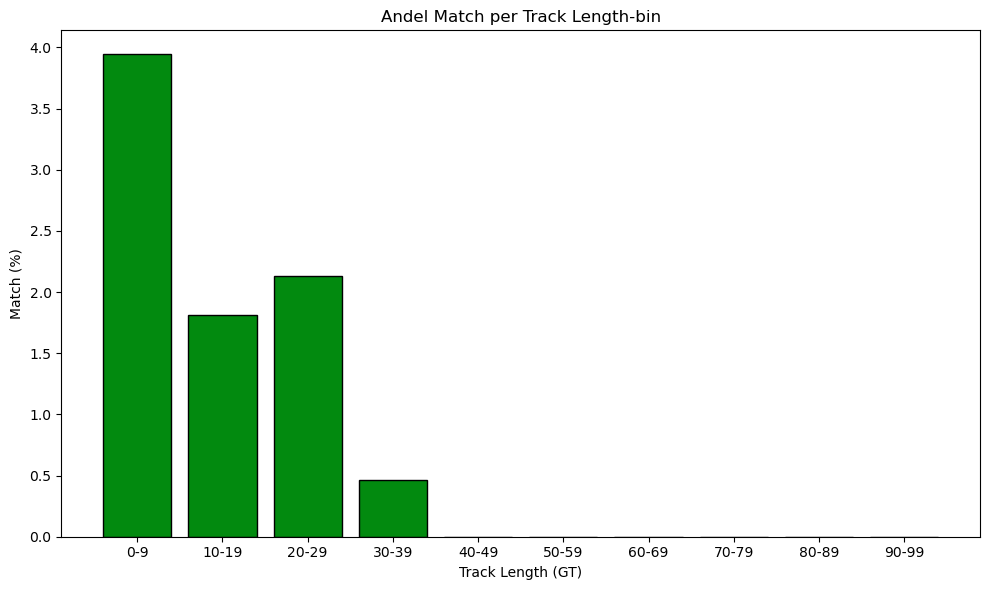

,Total,Match_True,Percent
bin,,,
0-9,1040,41,3.942308
10-19,993,18,1.812689
20-29,470,10,2.127660
30-39,217,1,0.460829
40-49,92,0,0.000000
50-59,36,0,0.000000
60-69,14,0,0.000000
70-79,13,0,0.000000
80-89,7,0,0.000000


In [7]:
bins = np.arange(0, 110, 10)
labels = np.array(("0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80-89","90-99"))

exploded = Match.explode("Track Length (GT)").reset_index(drop=True)
exploded["Track Length (GT)"] = exploded["Track Length (GT)"].astype(float)

exploded["bin"] = pd.cut(exploded["Track Length (GT)"], bins=bins, labels=labels, right=False)

total = exploded.groupby("bin").size()
match_true = exploded[exploded["Identical Match"] == True].groupby("bin").size()

result = pd.DataFrame({"Total": total, "Match_True": match_true}).fillna(0)
result["Percent"] = 100 * result["Match_True"] / result["Total"].replace(0, np.nan)

plt.figure(figsize=(10,6))
plt.bar(result.index, result["Percent"], color="#028A0F", edgecolor="black")
plt.xlabel("Track Length (GT)")
plt.ylabel("Match (%)")
plt.title("Andel Match per Track Length-bin")
plt.tight_layout()
plt.show()

display(result)

/tmp/ipykernel_910278/550165853.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = exploded.groupby("bin").size()
/tmp/ipykernel_910278/550165853.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_true = exploded[exploded["Match"] == True].groupby("bin").size()


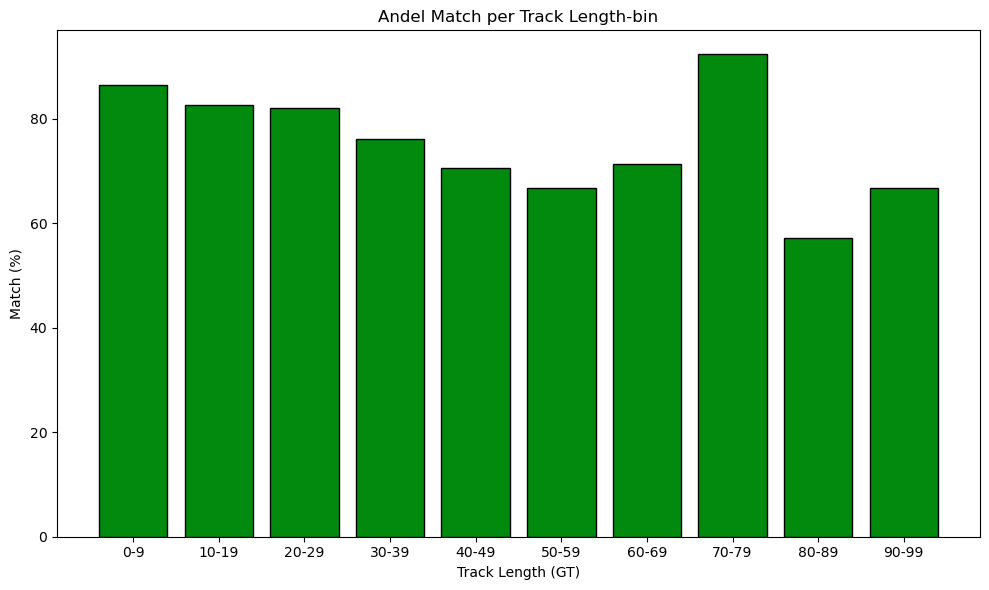

,Total,Match_True,Percent
bin,,,
0-9,1040,899,86.442308
10-19,993,820,82.578046
20-29,470,386,82.127660
30-39,217,165,76.036866
40-49,92,65,70.652174
50-59,36,24,66.666667
60-69,14,10,71.428571
70-79,13,12,92.307692
80-89,7,4,57.142857


In [8]:
bins = np.arange(0, 110, 10)
labels = np.array(("0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80-89","90-99"))

exploded = Match.explode("Track Length (GT)").reset_index(drop=True)
exploded["Track Length (GT)"] = exploded["Track Length (GT)"].astype(float)

exploded["bin"] = pd.cut(exploded["Track Length (GT)"], bins=bins, labels=labels, right=False)

total = exploded.groupby("bin").size()
match_true = exploded[exploded["Match"] == True].groupby("bin").size()

result = pd.DataFrame({"Total": total, "Match_True": match_true}).fillna(0)
result["Percent"] = 100 * result["Match_True"] / result["Total"].replace(0, np.nan)

plt.figure(figsize=(10,6))
plt.bar(result.index, result["Percent"], color="#028A0F", edgecolor="black")
plt.xlabel("Track Length (GT)")
plt.ylabel("Match (%)")
plt.title("Andel Match per Track Length-bin")
plt.tight_layout()
plt.show()
display(result)

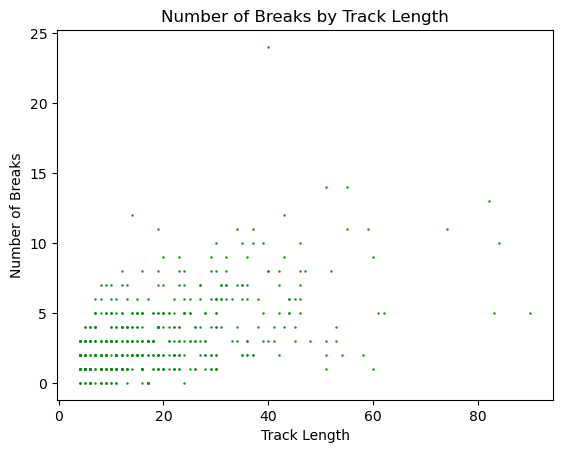

In [9]:
selected = ID_list[ID_list[:, 4] == False]
breaks = np.array([len(x) for x in selected[:,1]])-1
plt.scatter(selected[:,2],breaks, s = 0.5, color = "#028A0F") 
plt.xlabel("Track Length")
plt.ylabel("Number of Breaks")
plt.title("Number of Breaks by Track Length")
plt.savefig(f"{base} Base Plots/Break by Track Length.png")
plt.show()


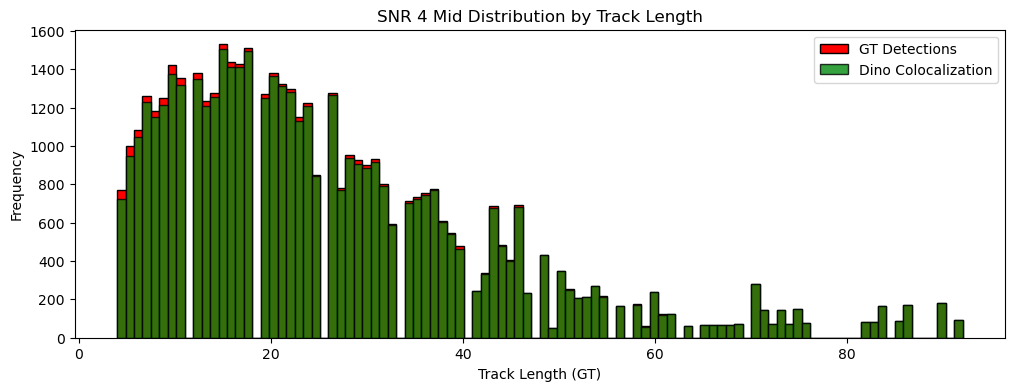

In [10]:
Comp_SNR = Comparison.copy()
Comp_SNR_coloc = Comp_SNR[Comp_SNR["Distance"]<threshold]

fig, ax = plt.subplots(1, 1, figsize=(12,4))
ax.hist(Comp_SNR[f"Track Length ({base})"], bins = 100, color="red", label = f"{base} Detections", edgecolor="black")
ax.hist(Comp_SNR_coloc[f"Track Length ({base})"], bins = 100, color="#028A0F",alpha=0.8, label = f"{sec} Colocalization",edgecolor="black")
ax.set_xlabel(f"Track Length ({base})")
ax.set_ylabel("Frequency")
ax.set_title(f"SNR 4 Mid Distribution by Track Length")
#ax.set_xticks(np.linspace(0,max(Comp_SNR[f"Track Length ({base})"])-1,), rotation=45)
ax.legend()
plt.savefig("SNR4_Mid_TL.png")
plt.show()

In [11]:
for col in ["ID (GT)", "ID (Dino)", "Track Length (GT)"]:
    #Match[col] = Match[col].apply(lambda x: x[0] if isinstance(x, list) else x)
    # Eller ännu säkrare (om det skulle kunna vara NaN, etc.):
    Match[col] = Match[col].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) and len(x) > 0 else np.nan)

# Nu kan du konvertera till int
Match[["ID (GT)", "ID (Dino)", "Track Length (GT)"]] = Match[["ID (GT)", "ID (Dino)", "Track Length (GT)"]].astype(float).astype(int)

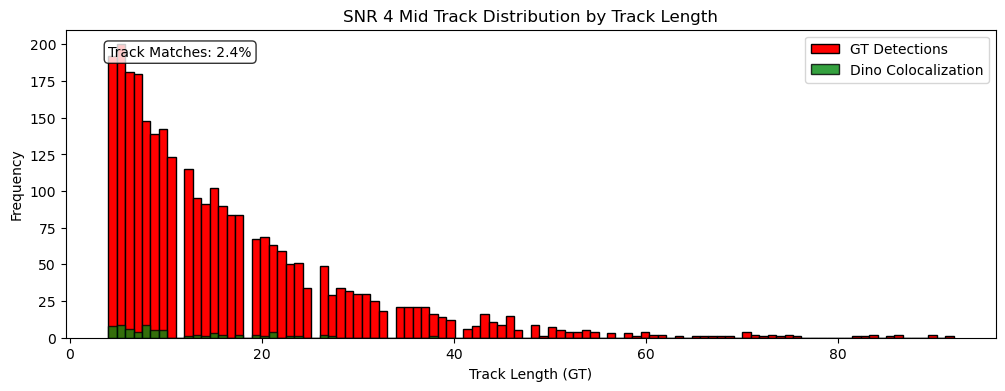

In [23]:
Comp = Match
Comp_non = Match[Match["Identical Match"]==True]

track_matches= round(100 * len(Comp_non) / len(Comp), 1)

# Beräkna min och max över BÅDA dataset
all_values = pd.concat([Comp[f"Track Length ({base})"], Comp_non[f"Track Length ({base})"]])
min_val = all_values.min()
max_val = all_values.max()

bins = np.linspace(min_val, max_val, 101)  # 100 bins = 101 kanter

fig, ax = plt.subplots(1, 1, figsize=(12,4))
ax.hist(Comp[f"Track Length ({base})"], bins=bins, color="red", label=f"{base} Detections", edgecolor="black")
ax.hist(Comp_non[f"Track Length ({base})"], bins=bins, color="#028A0F", alpha=0.8, label=f"{sec} Colocalization", edgecolor="black")
ax.text(0.20, 0.95, f'Track Matches: {Colocalization}%', 
        transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
ax.set_xlabel(f"Track Length ({base})")
ax.set_ylabel("Frequency")
ax.set_title(f"SNR 4 Mid Track Distribution by Track Length")
ax.legend()
plt.savefig("SNR4_Mid_TL.png")
plt.show()
